# 01_dataset_check.ipynb

В этом ноутбуке была выполнена первичная проверка структуры Running Exercise IMU Dataset. На этом этапе мы не обучали модель и не создавали финальный ML-датасет, а проверяли, как устроены исходные JSON-файлы, какие в них есть поля, сколько участников и классов присутствует, какие сенсоры доступны, как выглядят временные ряды акселерометра и гироскопа, а также можно ли на основе этих данных строить downstream-задачу классификации беговых движений.

## 0. Imports

In [1]:
from pathlib import Path
import json
import re
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 1. Найти папку с данными

Ноутбук ищет данные в нескольких типичных местах:
- `participant_data/`
- `data/raw/participant_data/`
- `data/raw/`


In [16]:
CANDIDATE_DIRS = [
    Path.cwd() / "participant_data",
    Path.cwd() / "data" / "raw" / "participant_data",
    Path.cwd() / "data" / "raw",
    Path.cwd().parent / "participant_data",
    Path.cwd().parent / "data" / "raw" / "participant_data",
    Path.cwd().parent / "data" / "raw",
]

RAW_DIR = None
for d in CANDIDATE_DIRS:
    if d.exists() and len(list(d.rglob("*.json"))) > 0:
        RAW_DIR = d
        break

if RAW_DIR is None:
    raise FileNotFoundError(
        "JSON files not found."
    )

json_files = sorted(RAW_DIR.rglob("*.json"))

print("RAW_DIR:", RAW_DIR.resolve())
print("num json files:", len(json_files))
print("first files:")
for p in json_files[:10]:
    print(" ", p.relative_to(RAW_DIR))

RAW_DIR: /Users/arsenij/Desktop/kurs-ml-ssl/participant_data
num json files: 147
first files:
  participant_1/carioca_left_2020-07-21--19-35-00.json
  participant_1/carioca_right_2020-07-21--19-34-39.json
  participant_1/heel_to_butt_2020-07-21--19-35-51.json
  participant_1/high_knee_run_2020-07-21--19-35-23.json
  participant_1/running_2020-07-21--19-33-34.json
  participant_1/sideskips_left_2020-07-21--19-34-16.json
  participant_1/sideskips_right_2020-07-21--19-33-54.json
  participant_10/carioca_left_2020-08-27--20-28-30.json
  participant_10/carioca_right_2020-08-27--20-28-50.json
  participant_10/heel_to_butt_2020-08-27--20-31-54.json


Каждая папка участника содержит по 7 JSON-файлов. Каждый JSON-файл соответствует одному типу бегового движения.

## 2. Проверить participants

In [3]:
def get_subject_id(path: Path) -> str:
    # Для структуры participant_data/participant_1/*.json
    for parent in [path.parent, *path.parents]:
        if parent.name.startswith("participant_"):
            return parent.name
    return "unknown"

participants = sorted({get_subject_id(p) for p in json_files})

print("num participant folders:", len(participants))
print(participants)

counts_by_participant = Counter(get_subject_id(p) for p in json_files)
pd.Series(counts_by_participant).sort_index()

num participant folders: 21
['participant_1', 'participant_10', 'participant_11', 'participant_12', 'participant_12_2', 'participant_13', 'participant_14', 'participant_15', 'participant_16', 'participant_17', 'participant_18', 'participant_19', 'participant_2', 'participant_20', 'participant_3', 'participant_4', 'participant_5', 'participant_6', 'participant_7', 'participant_8', 'participant_9']


participant_1       7
participant_10      7
participant_11      7
participant_12      7
participant_12_2    7
participant_13      7
participant_14      7
participant_15      7
participant_16      7
participant_17      7
participant_18      7
participant_19      7
participant_2       7
participant_20      7
participant_3       7
participant_4       7
participant_5       7
participant_6       7
participant_7       7
participant_8       7
participant_9       7
dtype: int64

В датасете обнаружена 21 папка участника. Каждый участник имеет по 7 JSON-файлов, то есть по одному файлу на каждый тип движения. Это подтверждается таблицей, где для каждого participant_* количество файлов равно 7.

По названию participant_12_2 может быть повторной записью или второй сессией того же участника participant_12. На этом этапе мы не удаляем эту папку, потому что она содержит полноценные данные. Однако в следующих ноутбуках для корректного разбиения train/validation эти две папки нужно считать одной группой. Иначе возможна утечка: одна запись одного и того же человека может попасть в train, а другая — в validation.

## 3. Открыть один JSON и вывести структуру ключей

In [4]:
sample_path = json_files[0]

with open(sample_path, "r") as f:
    sample = json.load(f)

print("sample file:", sample_path.relative_to(RAW_DIR))
print("top-level type:", type(sample))
print("top-level keys:", list(sample.keys()) if isinstance(sample, dict) else None)

sample file: participant_1/carioca_left_2020-07-21--19-35-00.json
top-level type: <class 'dict'>
top-level keys: ['datas', 'deviceId', 'endTime', 'label', 'note', 'startTime']


In [5]:
def walk_json(obj, prefix="", depth=0, max_depth=4):
    if depth > max_depth:
        return

    indent = "  " * depth

    if isinstance(obj, dict):
        for k, v in obj.items():
            name = f"{prefix}.{k}" if prefix else k
            print(f"{indent}{name}: {type(v).__name__}")
            walk_json(v, name, depth + 1, max_depth)

    elif isinstance(obj, list):
        print(f"{indent}{prefix}: list length = {len(obj)}")
        if len(obj) > 0:
            walk_json(obj[0], prefix + "[0]", depth + 1, max_depth)

walk_json(sample, max_depth=4)

datas: list
  datas: list length = 4
    datas[0].accData: dict
      datas[0].accData.timeStamp: list
        datas[0].accData.timeStamp: list length = 515
      datas[0].accData.xAxisData: list
        datas[0].accData.xAxisData: list length = 515
      datas[0].accData.yAxisData: list
        datas[0].accData.yAxisData: list length = 515
      datas[0].accData.zAxisData: list
        datas[0].accData.zAxisData: list length = 515
    datas[0].deviceMac: str
    datas[0].gyroData: dict
      datas[0].gyroData.timeStamp: list
        datas[0].gyroData.timeStamp: list length = 515
      datas[0].gyroData.xAxisData: list
        datas[0].gyroData.xAxisData: list length = 515
      datas[0].gyroData.yAxisData: list
        datas[0].gyroData.yAxisData: list length = 515
      datas[0].gyroData.zAxisData: list
        datas[0].gyroData.zAxisData: list length = 515
deviceId: str
endTime: str
label: str
note: str
startTime: str


Один JSON-файл представляет собой словарь с верхнеуровневыми ключами:

datas, deviceId, endTime, label, note, startTime.

Основное поле для ML-задачи — datas. Это список длины 4, то есть в каждом JSON-файле записаны данные от четырёх IMU-сенсоров. Каждый элемент datas[i] соответствует одному сенсору и содержит:

accData, gyroData, deviceMac.

Внутри accData и gyroData лежат временные ряды по трём осям:

xAxisData, yAxisData, zAxisData, а также timeStamp.

Значит, для одного сенсора можно собрать 6-канальный временной сигнал:

acc_x, acc_y, acc_z, gyro_x, gyro_y, gyro_z.

Именно такая структура подходит для задачи классификации временных рядов. Один timestep можно представить как 6-мерный вектор, а вся запись одного упражнения — как матрицу размера L × 6, где L — число временных отсчётов.

## 4. Собрать metadata по всем JSON

Здесь не трогаем сами сигналы полностью. Собираем только:
- `subject_id`;
- `label`;
- число sensors в `datas`;
- deviceMac;
- startTime / endTime;
- имя файла.

In [6]:
def label_from_filename(path: Path) -> str:
    # пример: high_knee_run_2020-07-21--19-35-23.json -> high_knee_run
    stem = path.stem
    m = re.match(r"(.+)_\d{4}-\d{2}-\d{2}--\d{2}-\d{2}-\d{2}$", stem)
    return m.group(1) if m else stem

def read_json(path: Path) -> dict:
    with open(path, "r") as f:
        return json.load(f)

rows = []

for path in json_files:
    obj = read_json(path)
    datas = obj.get("datas", [])
    device_macs = [d.get("deviceMac") for d in datas if isinstance(d, dict)]

    rows.append({
        "file": str(path),
        "relative_file": str(path.relative_to(RAW_DIR)),
        "subject_id": get_subject_id(path),
        "label_json": obj.get("label"),
        "label_from_filename": label_from_filename(path),
        "n_sensors": len(datas),
        "device_macs": device_macs,
        "startTime": obj.get("startTime"),
        "endTime": obj.get("endTime"),
        "deviceId": obj.get("deviceId"),
        "note": obj.get("note"),
    })

meta = pd.DataFrame(rows)
meta.head()

,file,relative_file,subject_id,label_json,label_from_filename,n_sensors,device_macs,startTime,endTime,deviceId,note
0,/Users/arsenij/Desktop/kurs-ml-ssl/participant...,participant_1/carioca_left_2020-07-21--19-35-0...,participant_1,carioca_left,carioca_left,4,"[D4:84:47:31:60:DA, E3:77:25:6A:E3:C5, C0:B0:D...",2020-07-21--19-35-00,2020-07-21--19-35-10,800615f68ded4c11,
1,/Users/arsenij/Desktop/kurs-ml-ssl/participant...,participant_1/carioca_right_2020-07-21--19-34-...,participant_1,carioca_right,carioca_right,4,"[D4:84:47:31:60:DA, E3:77:25:6A:E3:C5, C0:B0:D...",2020-07-21--19-34-39,2020-07-21--19-34-49,800615f68ded4c11,
2,/Users/arsenij/Desktop/kurs-ml-ssl/participant...,participant_1/heel_to_butt_2020-07-21--19-35-5...,participant_1,heel_to_butt,heel_to_butt,4,"[D4:84:47:31:60:DA, E3:77:25:6A:E3:C5, C0:B0:D...",2020-07-21--19-35-51,2020-07-21--19-36-01,800615f68ded4c11,
3,/Users/arsenij/Desktop/kurs-ml-ssl/participant...,participant_1/high_knee_run_2020-07-21--19-35-...,participant_1,high_knee_run,high_knee_run,4,"[D4:84:47:31:60:DA, E3:77:25:6A:E3:C5, C0:B0:D...",2020-07-21--19-35-23,2020-07-21--19-35-33,800615f68ded4c11,
4,/Users/arsenij/Desktop/kurs-ml-ssl/participant...,participant_1/running_2020-07-21--19-33-34.json,participant_1,running,running,4,"[D4:84:47:31:60:DA, E3:77:25:6A:E3:C5, C0:B0:D...",2020-07-21--19-33-34,2020-07-21--19-33-44,800615f68ded4c11,


In [7]:
print("num files:", len(meta))
print("num subjects:", meta["subject_id"].nunique())
print("num labels from JSON:", meta["label_json"].nunique())
print("n_sensors counts:")
display(meta["n_sensors"].value_counts().sort_index())

print("\nlabels:")
display(meta["label_json"].value_counts().sort_index())

print("\nfiles per subject:")
display(meta["subject_id"].value_counts().sort_index())

print("\nlabel_json == label_from_filename?")
display((meta["label_json"] == meta["label_from_filename"]).value_counts())

num files: 147
num subjects: 21
num labels from JSON: 7
n_sensors counts:


n_sensors
4    147
Name: count, dtype: int64


labels:


label_json
carioca_left       21
carioca_right      21
heel_to_butt       21
high_knee_run      21
running            21
sideskips_left     21
sideskips_right    21
Name: count, dtype: int64


files per subject:


subject_id
participant_1       7
participant_10      7
participant_11      7
participant_12      7
participant_12_2    7
participant_13      7
participant_14      7
participant_15      7
participant_16      7
participant_17      7
participant_18      7
participant_19      7
participant_2       7
participant_20      7
participant_3       7
participant_4       7
participant_5       7
participant_6       7
participant_7       7
participant_8       7
participant_9       7
Name: count, dtype: int64


label_json == label_from_filename?


True    147
Name: count, dtype: int64



По всем JSON-файлам были собраны metadata: `subject_id`, `label`, число сенсоров, `deviceMac`, `startTime`, `endTime` и имя файла. Проверка показала, что label из JSON совпадает с label из имени файла для всех 147 файлов. Всего есть 7 классов, каждый представлен 21 файлом. На уровне файлов датасет сбалансирован, но после нарезки окон баланс нужно будет проверить заново.

## 5. Проверить sensor information

В JSON есть `datas`, внутри каждого элемента есть `deviceMac`, `accData`, `gyroData`.

Но в самом JSON может не быть человекочитаемого поля вроде `right_ankle`.
Поэтому сначала проверяем, есть ли вообще строки с `ankle`, `right`, `left`, `foot`, `leg` среди ключей/значений.

In [8]:
def flatten_values(obj):
    values = []
    if isinstance(obj, dict):
        for k, v in obj.items():
            values.append(str(k))
            values.extend(flatten_values(v))
    elif isinstance(obj, list):
        for item in obj[:10]:
            values.extend(flatten_values(item))
    else:
        values.append(str(obj))
    return values

keywords = ["ankle", "right", "left", "foot", "leg", "sensor", "placement", "location"]
all_text = " ".join(flatten_values(sample)).lower()

for kw in keywords:
    print(f"{kw:>10}:", kw in all_text)

print("\nDevice MACs in sample:")
for i, d in enumerate(sample.get("datas", [])):
    print(i, d.get("deviceMac"))

     ankle: False
     right: False
      left: True
      foot: False
       leg: False
    sensor: False
 placement: False
  location: False

Device MACs in sample:
0 D4:84:47:31:60:DA
1 E3:77:25:6A:E3:C5
2 C0:B0:DB:50:EB:35
3 D4:FC:C7:02:12:59


In [9]:
sensor_rows = []

for _, row in meta.iterrows():
    path = Path(row["file"])
    obj = read_json(path)

    for sensor_idx, d in enumerate(obj.get("datas", [])):
        acc = d.get("accData", {})
        gyro = d.get("gyroData", {})

        sensor_rows.append({
            "file": row["relative_file"],
            "subject_id": row["subject_id"],
            "label": row["label_json"],
            "sensor_idx": sensor_idx,
            "deviceMac": d.get("deviceMac"),
            "acc_len": len(acc.get("timeStamp", [])),
            "gyro_len": len(gyro.get("timeStamp", [])),
        })

sensor_meta = pd.DataFrame(sensor_rows)

display(sensor_meta.head())
print("sensor_idx counts:")
display(sensor_meta["sensor_idx"].value_counts().sort_index())

print("unique deviceMac count:", sensor_meta["deviceMac"].nunique())
display(sensor_meta.groupby(["subject_id", "sensor_idx"])["deviceMac"].first().unstack())

,file,subject_id,label,sensor_idx,deviceMac,acc_len,gyro_len
0,participant_1/carioca_left_2020-07-21--19-35-0...,participant_1,carioca_left,0,D4:84:47:31:60:DA,515,515
1,participant_1/carioca_left_2020-07-21--19-35-0...,participant_1,carioca_left,1,E3:77:25:6A:E3:C5,512,512
2,participant_1/carioca_left_2020-07-21--19-35-0...,participant_1,carioca_left,2,C0:B0:DB:50:EB:35,520,520
3,participant_1/carioca_left_2020-07-21--19-35-0...,participant_1,carioca_left,3,D4:FC:C7:02:12:59,512,512
4,participant_1/carioca_right_2020-07-21--19-34-...,participant_1,carioca_right,0,D4:84:47:31:60:DA,512,512


sensor_idx counts:


sensor_idx
0    147
1    147
2    147
3    147
Name: count, dtype: int64

unique deviceMac count: 4


sensor_idx,0,1,2,3
subject_id,,,,
participant_1,D4:84:47:31:60:DA,E3:77:25:6A:E3:C5,C0:B0:DB:50:EB:35,D4:FC:C7:02:12:59
participant_10,E3:77:25:6A:E3:C5,D4:FC:C7:02:12:59,C0:B0:DB:50:EB:35,D4:84:47:31:60:DA
participant_11,D4:84:47:31:60:DA,D4:FC:C7:02:12:59,C0:B0:DB:50:EB:35,E3:77:25:6A:E3:C5
participant_12,D4:FC:C7:02:12:59,C0:B0:DB:50:EB:35,E3:77:25:6A:E3:C5,D4:84:47:31:60:DA
participant_12_2,D4:FC:C7:02:12:59,C0:B0:DB:50:EB:35,E3:77:25:6A:E3:C5,D4:84:47:31:60:DA
participant_13,C0:B0:DB:50:EB:35,D4:84:47:31:60:DA,E3:77:25:6A:E3:C5,D4:FC:C7:02:12:59
participant_14,C0:B0:DB:50:EB:35,D4:FC:C7:02:12:59,E3:77:25:6A:E3:C5,D4:84:47:31:60:DA
participant_15,E3:77:25:6A:E3:C5,D4:84:47:31:60:DA,C0:B0:DB:50:EB:35,D4:FC:C7:02:12:59
participant_16,D4:FC:C7:02:12:59,D4:84:47:31:60:DA,E3:77:25:6A:E3:C5,C0:B0:DB:50:EB:35


В каждом файле есть 4 сенсора: `sensor_idx = 0, 1, 2, 3`. Однако в JSON нет явного поля с расположением сенсора на теле, например `right ankle` или `left ankle`. Поэтому в MVP нельзя утверждать, что выбранный сенсор соответствует конкретной анатомической позиции. Для первой версии проекта выбран фиксированный `sensor_idx = 0` как один источник IMU-сигнала. Sensor fusion и уточнение расположения сенсоров оставляем на будущее.

In [10]:
SENSOR_IDX = 0  # TODO: заменить на индекс right ankle, когда будет известен mapping

print("Selected sensor_idx:", SENSOR_IDX)
display(sensor_meta[sensor_meta["sensor_idx"] == SENSOR_IDX].head())

Selected sensor_idx: 0


,file,subject_id,label,sensor_idx,deviceMac,acc_len,gyro_len
0,participant_1/carioca_left_2020-07-21--19-35-0...,participant_1,carioca_left,0,D4:84:47:31:60:DA,515,515
4,participant_1/carioca_right_2020-07-21--19-34-...,participant_1,carioca_right,0,D4:84:47:31:60:DA,512,512
8,participant_1/heel_to_butt_2020-07-21--19-35-5...,participant_1,heel_to_butt,0,D4:84:47:31:60:DA,512,512
12,participant_1/high_knee_run_2020-07-21--19-35-...,participant_1,high_knee_run,0,D4:84:47:31:60:DA,513,513
16,participant_1/running_2020-07-21--19-33-34.json,participant_1,running,0,D4:84:47:31:60:DA,510,510


## 6. Проверить timestamp и sampling rate для выбранного sensor_idx

Здесь считаем примерный sampling rate по медианному шагу timestamp.

Если timestamp в миллисекундах, то:

$$
fs \approx \frac{1000}{median(\Delta t)}
$$

In [11]:
def estimate_fs_from_timestamps(timestamps):
    t = np.asarray(timestamps, dtype=np.float64)
    if len(t) < 2:
        return np.nan, np.nan

    dt = np.diff(t)
    dt = dt[dt > 0]

    if len(dt) == 0:
        return np.nan, np.nan

    median_dt = np.median(dt)

    # эвристика: unix timestamp в миллисекундах или timestamp с шагом ~19 ms
    fs = 1000.0 / median_dt

    return median_dt, fs


fs_rows = []

for _, row in meta.iterrows():
    obj = read_json(Path(row["file"]))
    datas = obj.get("datas", [])

    if SENSOR_IDX >= len(datas):
        continue

    d = datas[SENSOR_IDX]
    acc_t = d.get("accData", {}).get("timeStamp", [])
    gyro_t = d.get("gyroData", {}).get("timeStamp", [])

    acc_dt, acc_fs = estimate_fs_from_timestamps(acc_t)
    gyro_dt, gyro_fs = estimate_fs_from_timestamps(gyro_t)

    fs_rows.append({
        "file": row["relative_file"],
        "subject_id": row["subject_id"],
        "label": row["label_json"],
        "sensor_idx": SENSOR_IDX,
        "acc_len": len(acc_t),
        "gyro_len": len(gyro_t),
        "acc_median_dt": acc_dt,
        "gyro_median_dt": gyro_dt,
        "acc_fs_est": acc_fs,
        "gyro_fs_est": gyro_fs,
    })

fs_df = pd.DataFrame(fs_rows)
display(fs_df.head())

print("acc fs describe:")
display(fs_df["acc_fs_est"].describe())

print("gyro fs describe:")
display(fs_df["gyro_fs_est"].describe())

,file,subject_id,label,sensor_idx,acc_len,gyro_len,acc_median_dt,gyro_median_dt,acc_fs_est,gyro_fs_est
0,participant_1/carioca_left_2020-07-21--19-35-0...,participant_1,carioca_left,0,515,515,19.0,19.0,52.631579,52.631579
1,participant_1/carioca_right_2020-07-21--19-34-...,participant_1,carioca_right,0,512,512,19.0,19.0,52.631579,52.631579
2,participant_1/heel_to_butt_2020-07-21--19-35-5...,participant_1,heel_to_butt,0,512,512,19.0,19.0,52.631579,52.631579
3,participant_1/high_knee_run_2020-07-21--19-35-...,participant_1,high_knee_run,0,513,513,19.0,19.0,52.631579,52.631579
4,participant_1/running_2020-07-21--19-33-34.json,participant_1,running,0,510,510,19.0,19.0,52.631579,52.631579


acc fs describe:


count    1.470000e+02
mean     5.263158e+01
std      7.129719e-15
min      5.263158e+01
25%      5.263158e+01
50%      5.263158e+01
75%      5.263158e+01
max      5.263158e+01
Name: acc_fs_est, dtype: float64

gyro fs describe:


count    1.470000e+02
mean     5.263158e+01
std      7.129719e-15
min      5.263158e+01
25%      5.263158e+01
50%      5.263158e+01
75%      5.263158e+01
max      5.263158e+01
Name: gyro_fs_est, dtype: float64

## 7. Проверить длины сигналов и баланс labels/subjects

Для будущих окон важно понять:
- хватает ли длины записи для окна 1 секунда;
- одинаковое ли число файлов на класс;
- нет ли странных участников.

In [12]:
print("acc_len describe:")
display(fs_df["acc_len"].describe())

print("gyro_len describe:")
display(fs_df["gyro_len"].describe())

print("files by label:")
display(meta["label_json"].value_counts().sort_index())

print("files by subject and label:")
subject_label_table = meta.pivot_table(
    index="subject_id",
    columns="label_json",
    values="relative_file",
    aggfunc="count",
    fill_value=0,
)
display(subject_label_table)

acc_len describe:


count    147.000000
mean     510.904762
std       37.033183
min       74.000000
25%      512.000000
50%      514.000000
75%      516.000000
max      525.000000
Name: acc_len, dtype: float64

gyro_len describe:


count    147.000000
mean     510.904762
std       37.033183
min       74.000000
25%      512.000000
50%      514.000000
75%      516.000000
max      525.000000
Name: gyro_len, dtype: float64

files by label:


label_json
carioca_left       21
carioca_right      21
heel_to_butt       21
high_knee_run      21
running            21
sideskips_left     21
sideskips_right    21
Name: count, dtype: int64

files by subject and label:


label_json,carioca_left,carioca_right,heel_to_butt,high_knee_run,running,sideskips_left,sideskips_right
subject_id,,,,,,,
participant_1,1,1,1,1,1,1,1
participant_10,1,1,1,1,1,1,1
participant_11,1,1,1,1,1,1,1
participant_12,1,1,1,1,1,1,1
participant_12_2,1,1,1,1,1,1,1
participant_13,1,1,1,1,1,1,1
participant_14,1,1,1,1,1,1,1
participant_15,1,1,1,1,1,1,1
participant_16,1,1,1,1,1,1,1


Большинство записей имеют длину около 510–515 отсчётов, что соответствует примерно 10 секундам сигнала при частоте около 52.6 Hz. При этом есть отдельные короткие записи, минимальная длина — 74 отсчёта. На уровне файлов каждый класс представлен 21 разом, и у каждого участника есть один файл каждого класса. После нарезки окон нужно повторно проверить баланс, потому что короткие записи дадут меньше окон.

## 8. Быстро построить один сигнал

Это sanity-check: смотрим, что acc/gyro читаются и имеют ожидаемую форму.

In [13]:
def load_one_sensor_dataframe(path: Path, sensor_idx: int) -> pd.DataFrame:
    obj = read_json(path)
    datas = obj.get("datas", [])

    if sensor_idx >= len(datas):
        raise IndexError(f"sensor_idx={sensor_idx} out of range for {path}")

    d = datas[sensor_idx]

    acc = d["accData"]
    gyro = d["gyroData"]

    # Для MVP предполагаем, что acc и gyro имеют близкие timestamp/длины.
    # Если длины отличаются, обрезаем до минимальной длины.
    n = min(
        len(acc["timeStamp"]),
        len(acc["xAxisData"]),
        len(acc["yAxisData"]),
        len(acc["zAxisData"]),
        len(gyro["timeStamp"]),
        len(gyro["xAxisData"]),
        len(gyro["yAxisData"]),
        len(gyro["zAxisData"]),
    )

    df = pd.DataFrame({
        "timestamp_acc": acc["timeStamp"][:n],
        "timestamp_gyro": gyro["timeStamp"][:n],
        "acc_x": acc["xAxisData"][:n],
        "acc_y": acc["yAxisData"][:n],
        "acc_z": acc["zAxisData"][:n],
        "gyro_x": gyro["xAxisData"][:n],
        "gyro_y": gyro["yAxisData"][:n],
        "gyro_z": gyro["zAxisData"][:n],
    })

    df["subject_id"] = get_subject_id(path)
    df["label"] = read_json(path).get("label")
    df["sensor_idx"] = sensor_idx
    df["deviceMac"] = d.get("deviceMac")
    df["file"] = str(path.relative_to(RAW_DIR))

    return df

one_df = load_one_sensor_dataframe(sample_path, SENSOR_IDX)
display(one_df.head())
display(one_df.describe())

,timestamp_acc,timestamp_gyro,acc_x,acc_y,acc_z,gyro_x,gyro_y,gyro_z,subject_id,label,sensor_idx,deviceMac,file
0,1595352898619,1595352898619,6123,382,1993,1643,-1929,-3954,participant_1,carioca_left,0,D4:84:47:31:60:DA,participant_1/carioca_left_2020-07-21--19-35-0...
1,1595352898638,1595352898638,5536,-3662,2188,2279,-1079,-2370,participant_1,carioca_left,0,D4:84:47:31:60:DA,participant_1/carioca_left_2020-07-21--19-35-0...
2,1595352898657,1595352898657,4085,-3014,3580,4411,-776,140,participant_1,carioca_left,0,D4:84:47:31:60:DA,participant_1/carioca_left_2020-07-21--19-35-0...
3,1595352898676,1595352898676,3371,-1731,4555,2103,1037,2325,participant_1,carioca_left,0,D4:84:47:31:60:DA,participant_1/carioca_left_2020-07-21--19-35-0...
4,1595352898695,1595352898695,3715,-546,4925,1238,1658,3760,participant_1,carioca_left,0,D4:84:47:31:60:DA,participant_1/carioca_left_2020-07-21--19-35-0...


,timestamp_acc,timestamp_gyro,acc_x,acc_y,acc_z,gyro_x,gyro_y,gyro_z,sensor_idx
count,5.150000e+02,5.150000e+02,515.000000,515.000000,515.000000,515.000000,515.000000,515.000000,515.0
mean,1.595353e+12,1.595353e+12,3514.143689,-777.407767,-1033.000000,44.328155,52.629126,31.633010,0.0
std,2.879721e+03,2.879721e+03,1670.821033,2198.443540,3549.997743,2667.034480,2194.494980,2870.437415,0.0
min,1.595353e+12,1.595353e+12,-1634.000000,-11030.000000,-7768.000000,-8147.000000,-4106.000000,-5558.000000,0.0
25%,1.595353e+12,1.595353e+12,2757.500000,-1690.000000,-4099.500000,-1198.500000,-1934.000000,-2188.500000,0.0
50%,1.595353e+12,1.595353e+12,3816.000000,-432.000000,-1068.000000,144.000000,-444.000000,-65.000000,0.0
75%,1.595353e+12,1.595353e+12,4682.500000,531.500000,2106.000000,1828.000000,2279.500000,2280.000000,0.0
max,1.595353e+12,1.595353e+12,7010.000000,4744.000000,6508.000000,5649.000000,4101.000000,6026.000000,0.0


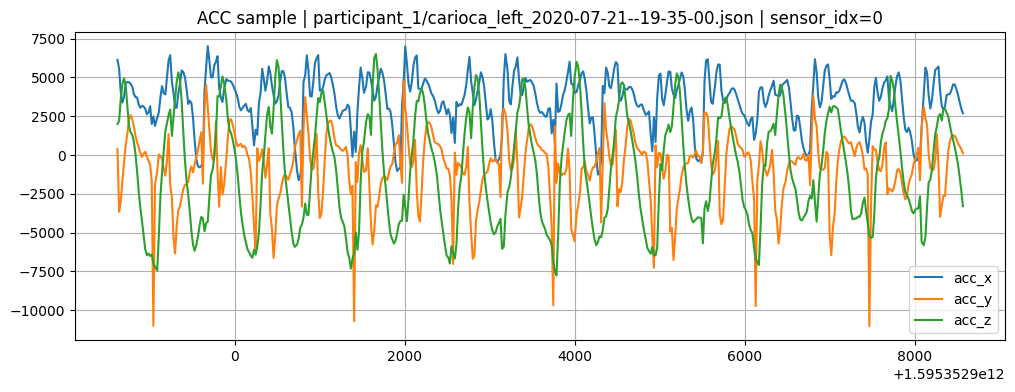

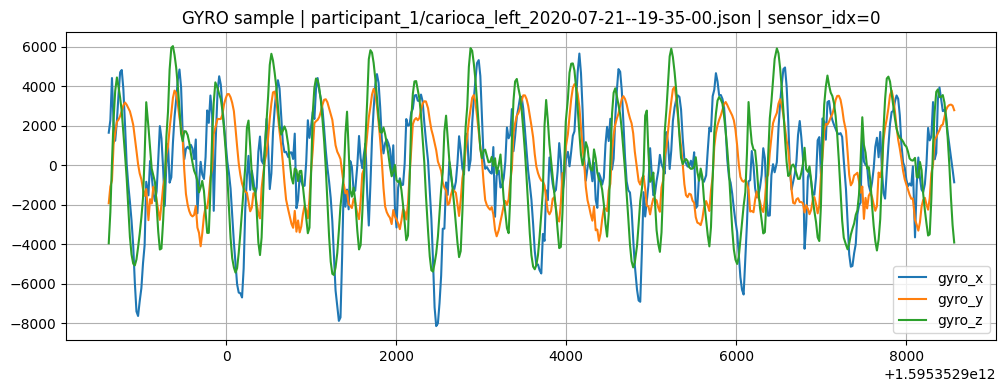

In [14]:
plt.figure(figsize=(12, 4))
plt.plot(one_df["timestamp_acc"], one_df["acc_x"], label="acc_x")
plt.plot(one_df["timestamp_acc"], one_df["acc_y"], label="acc_y")
plt.plot(one_df["timestamp_acc"], one_df["acc_z"], label="acc_z")
plt.title(f"ACC sample | {one_df['file'].iloc[0]} | sensor_idx={SENSOR_IDX}")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(one_df["timestamp_gyro"], one_df["gyro_x"], label="gyro_x")
plt.plot(one_df["timestamp_gyro"], one_df["gyro_y"], label="gyro_y")
plt.plot(one_df["timestamp_gyro"], one_df["gyro_z"], label="gyro_z")
plt.title(f"GYRO sample | {one_df['file'].iloc[0]} | sensor_idx={SENSOR_IDX}")
plt.legend()
plt.grid(True)
plt.show()

Графики акселерометра и гироскопа показывают, что данные имеют выраженную временную структуру и периодические колебания, характерные для беговых движений. Каналы `acc_x`, `acc_y`, `acc_z`, `gyro_x`, `gyro_y`, `gyro_z` читаются корректно. Это подтверждает, что данные подходят для модели временных рядов, например 1D-CNN. Перед обучением потребуется нормализация сигналов.

# Общий вывод

В первом ноутбуке была проверена структура Running Exercise IMU Dataset. Датасет содержит 147 JSON-файлов, сгруппированных по 21 participant-папке. У каждого участника есть 7 файлов, соответствующих 7 классам беговых движений: `carioca_left`, `carioca_right`, `heel_to_butt`, `high_knee_run`, `running`, `sideskips_left`, `sideskips_right`.

Каждый JSON содержит 4 IMU-сенсора. Для одного сенсора доступны данные акселерометра и гироскопа по трём осям, то есть можно сформировать 6-канальный временной ряд: `acc_x`, `acc_y`, `acc_z`, `gyro_x`, `gyro_y`, `gyro_z`.

В JSON нет явного указания расположения сенсоров на теле, поэтому в MVP выбран фиксированный `sensor_idx = 0` без утверждения, что это конкретная анатомическая позиция. Частота дискретизации оценивается примерно как 52.6 Hz, поэтому в дальнейшем используется окно `WINDOW_SIZE = 52`, соответствующее примерно 1 секунде сигнала.

Классы на уровне файлов сбалансированы: каждый класс представлен 21 записью. При этом есть отдельные короткие записи, поэтому после нарезки окон баланс нужно проверить повторно. Также обнаружен `participant_12_2`, который в следующих ноутбуках нужно объединить с `participant_12` в одну `group_id`, чтобы избежать возможной утечки между train и validation.

Итог: датасет подходит для MVP-задачи классификации беговых движений по IMU-сигналам. Дальнейший pipeline: `JSON → sensor_idx = 0 → 6 каналов → sliding windows → group-wise split → supervised baseline → SSL pretraining → fine-tuning`.